# 04 — Does the Cross-Sectional Signal Survive Costs?

Notebook 08c found a weak but statistically real cross-sectional signal: rank IC ≈ 0.03, beating a momentum baseline. **Rank IC is a gross number.** A signal that requires trading the whole book every day can be statistically real and still lose money once transaction costs are paid.

This notebook answers the only question that decides whether the 08c signal is worth anything: **what is the break-even transaction cost?** Below it the strategy makes money; above it, costs win. Three pieces:

1. **Signal decay** — how long the prediction stays useful. Determines how often you must rebalance.
2. **Turnover** — how much of the book changes each period. The cost multiplier.
3. **Cost-adjusted return and break-even** — gross spread return minus turnover × cost, swept across realistic cost levels.

**The decisive number is break-even cost in basis points.** For liquid US large caps, realistic all-in cost is roughly 5–20 bps round-trip. Above 20 bps break-even the signal is robust; 5–20 is marginal (works only with cheap execution); below 5 it is a mirage.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

In [5]:
# Ensure the project root is on the import path so `src` can be imported.
PROJECT_ROOT = Path.cwd().resolve()
for parent in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError('Run this notebook from inside the StockForecastRisk repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.forecast_engine.features.schema import FEATURE_NAMES
from src.forecast_engine.data.loader import PROCESSED_FEATURES_PATH, load_processed_features

data = load_processed_features()
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values(["symbol", "date"]).reset_index(drop=True)
data["log_return"] = data.groupby("symbol")["adj_close"].transform(lambda s: np.log(s / s.shift(1)))
feature_cols = [c for c in FEATURE_NAMES if c in data.columns and not data[c].isna().all()]


print(f'Loaded {len(data):,} rows for {data["symbol"].nunique():,} tickers')
print(f"Dates: {data['date'].min().date()} to {data['date'].max().date()}")
print(f'Source: {PROCESSED_FEATURES_PATH}')
data.head()

Loaded 622,731 rows for 502 tickers
Dates: 2021-07-19 to 2026-07-17
Source: D:\StockForecastRisk\data\processed\sp500_features.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,...,fed_funds_rate,vix_term_ratio,yield_curve_slope,vix_change_5d,hy_credit_spread_change_5d,yield_curve_slope_change_5d,vix_change_20d,hy_credit_spread_change_20d,yield_curve_slope_change_20d,log_return
0,2021-07-19,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,142.434052,147.580002,147.970001,146.949997,147.660004,...,0.1,0.903614,0.98,6.17,NaN,-0.16,6.48,NaN,-0.24,NaN
1,2021-07-20,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.094101,149.300003,151.250000,147.830002,148.449997,...,0.1,0.850431,1.03,2.72,NaN,-0.05,3.90,NaN,-0.17,0.011587
2,2021-07-21,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.756302,148.949997,149.910004,147.600006,149.490005,...,0.1,0.818930,1.08,-0.54,NaN,0.02,2.43,NaN,-0.15,-0.002347
3,2021-07-22,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,145.059174,150.300003,150.500000,148.669998,149.710007,...,0.1,0.809241,1.07,-0.76,NaN,0.01,2.62,NaN,-0.13,0.009022
4,2021-07-23,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,146.999084,152.309998,152.410004,150.429993,150.589996,...,0.1,0.794457,1.08,-1.25,NaN,0.02,2.13,NaN,-0.12,0.013285


## Regenerate the 03 prediction

The cost analysis needs an out-of-sample predicted score for every (day, ticker). This repeats 08c's walk-forward exactly — XGBoost on the relative forward return — and keeps the out-of-sample predictions, which are what a live strategy would actually have traded on.

In [6]:
HORIZON = 20

fwd = data.groupby("symbol")["log_return"].transform(lambda s: s.shift(-HORIZON).rolling(HORIZON).sum())
data["fwd_20d"] = np.exp(fwd) - 1.0
data["fwd_rel"] = data.groupby("date")["fwd_20d"].transform(lambda s: s - s.mean())
# Shorter-horizon forward returns for the decay curve.
for h in (1, 5, 10, 20):
    fh = data.groupby("symbol")["log_return"].transform(lambda s: s.shift(-h).rolling(h).sum())
    data[f"fwd_{h}d_ret"] = np.exp(fh) - 1.0

panel = data.dropna(subset=feature_cols + ["fwd_rel"]).reset_index(drop=True)

def walk_forward(frame, n_splits=5, purge_days=HORIZON):
    dates = np.sort(frame["date"].unique())
    edges = np.array_split(dates, n_splits + 1)
    for fold in range(n_splits):
        cutoff = edges[fold][-1] - pd.Timedelta(days=purge_days)
        tr = frame.index[frame["date"] <= cutoff]
        te = frame.index[frame["date"].isin(edges[fold + 1])]
        if len(tr) and len(te):
            yield tr, te

panel["pred"] = np.nan
for tr, te in walk_forward(panel):
    scaler = StandardScaler().fit(panel.loc[tr, feature_cols])
    model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
                         colsample_bytree=0.8, random_state=0, verbosity=0)
    model.fit(scaler.transform(panel.loc[tr, feature_cols]), panel.loc[tr, "fwd_rel"])
    panel.loc[te, "pred"] = model.predict(scaler.transform(panel.loc[te, feature_cols]))

scored = panel.dropna(subset=["pred"]).copy()
print(f"out-of-sample predictions: {len(scored):,} rows over {scored['date'].nunique()} days")

out-of-sample predictions: 425,806 rows over 862 days


## 1. Signal decay

IC of the prediction against forward returns at 1, 5, 10, and 20 days. A signal that only shows up at 20 days but is flat at 1 day means the edge is slow — which is *good* for costs, because you can rebalance slowly. A signal concentrated at 1 day decays fast and forces expensive daily trading.

,mean_ic,t_stat
horizon_days,,
1,0.0107,1.9118
5,0.0202,3.6663
10,0.0247,4.6659
20,0.0301,6.3367


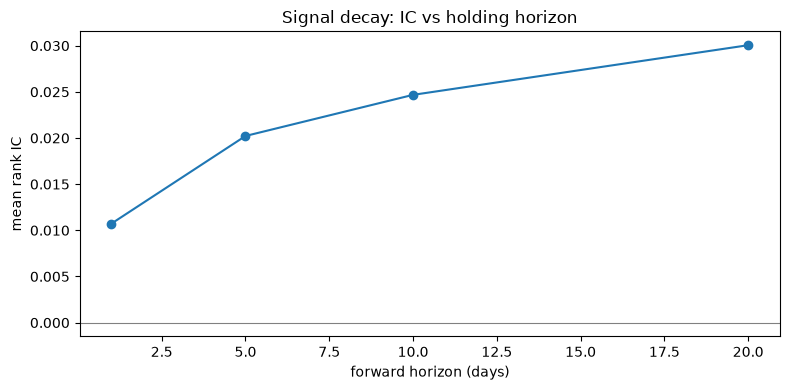

IC peaks at 20-day horizon -> rebalancing near that cadence balances
signal capture against turnover cost.


In [7]:
decay_rows = []
for h in (1, 5, 10, 20):
    col = f"fwd_{h}d_ret"
    ic = scored.groupby("date").apply(
        lambda g: stats.spearmanr(g["pred"], g[col]).correlation if g[["pred", col]].dropna().shape[0] > 10 else np.nan
    ).dropna()
    decay_rows.append({"horizon_days": h, "mean_ic": ic.mean(), "t_stat": ic.mean() / (ic.std() / np.sqrt(len(ic)))})
decay = pd.DataFrame(decay_rows).set_index("horizon_days")
display(decay.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(decay.index, decay["mean_ic"], marker="o")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("forward horizon (days)"); ax.set_ylabel("mean rank IC")
ax.set_title("Signal decay: IC vs holding horizon")
plt.tight_layout(); plt.show()

peak_h = decay["mean_ic"].abs().idxmax()
print(f"IC peaks at {peak_h}-day horizon -> rebalancing near that cadence balances")
print("signal capture against turnover cost.")

## 2. Turnover

Build a long-short portfolio from the predictions each day — long the top decile, short the bottom, equally weighted within each leg — and measure how much the weights change day to day. Turnover is `0.5 * sum |w_t - w_{t-1}|`: the fraction of the book traded each rebalance, and the multiplier on every cost.

In [8]:
def decile_weights(group, decile=0.1):
    ranks = group["pred"].rank(pct=True)
    weights = pd.Series(0.0, index=group.index)
    longs, shorts = ranks >= (1 - decile), ranks <= decile
    if longs.sum():
        weights[longs] = 1.0 / longs.sum()
    if shorts.sum():
        weights[shorts] = -1.0 / shorts.sum()
    return weights

scored["weight"] = scored.groupby("date", group_keys=False).apply(decile_weights)
weights_wide = scored.pivot_table(index="date", columns="symbol", values="weight", fill_value=0).sort_index()
daily_turnover = 0.5 * weights_wide.diff().abs().sum(axis=1)

print(f"mean daily turnover: {daily_turnover.mean():.3f} "
      f"(fraction of book traded per rebalance)")
print(f"a value near 1.0 means the book is almost fully replaced daily -- "
      f"expensive to run.")

mean daily turnover: 0.389 (fraction of book traded per rebalance)
a value near 1.0 means the book is almost fully replaced daily -- expensive to run.


## 3. Cost-adjusted return and break-even

Gross spread return is the daily long-short P&L. Net return subtracts `turnover × cost_per_trade`. Sweeping the cost from 1 to 20 bps shows where the strategy stops being profitable; the **break-even cost** is the single summary number.

In [9]:
returns_wide = scored.pivot_table(index="date", columns="symbol", values="fwd_1d_ret", fill_value=0).sort_index()
common = weights_wide.index.intersection(returns_wide.index)
daily_pnl = (weights_wide.loc[common] * returns_wide.loc[common]).sum(axis=1)
gross_daily = daily_pnl.mean()
mean_turnover = daily_turnover.loc[common].mean()

print(f"gross daily spread return : {gross_daily * 1e4:+.2f} bps")
print(f"mean daily turnover       : {mean_turnover:.3f}\n")

cost_rows = []
for cost_bps in (1, 3, 5, 10, 15, 20):
    net = gross_daily - mean_turnover * cost_bps / 1e4
    cost_rows.append({"cost_bps": cost_bps, "net_bps_per_day": net * 1e4,
                      "annualised_pct": net * 252 * 100, "profitable": net > 0})
cost_table = pd.DataFrame(cost_rows).set_index("cost_bps")
display(cost_table.round(2))

break_even = gross_daily / (mean_turnover / 1e4) if mean_turnover > 0 else np.inf
print(f"\nBREAK-EVEN round-trip cost: {break_even:.1f} bps")

gross daily spread return : +6.59 bps
mean daily turnover       : 0.389



,net_bps_per_day,annualised_pct,profitable
cost_bps,,,
1,6.20,15.62,True
3,5.42,13.66,True
5,4.64,11.70,True
10,2.70,6.80,True
15,0.75,1.90,True
20,-1.19,-3.00,False



BREAK-EVEN round-trip cost: 16.9 bps


## ★ Verdict

In [10]:
print(f"break-even cost: {break_even:.1f} bps round-trip\n")
if break_even > 20:
    print("ROBUST -- survives realistic large-cap costs (5-20 bps). The 08c signal is")
    print("economically real, not just statistically real. Worth a proper allocation study.")
elif break_even > 5:
    print("MARGINAL -- profitable only with cheap execution. Real but fragile; it would")
    print("need low-cost implementation and careful turnover control to be usable.")
else:
    print("MIRAGE -- costs eat the signal. The IC 0.03 from 08c is statistically real but")
    print("economically empty at this turnover. Confirms the efficient-market reading:")
    print("the cross-section is not arbitrageable with these features after costs.")

# Slow-rebalance check: does holding longer cut turnover enough to help?
print("\nWould slower rebalancing help? Compare IC capture vs turnover:")
print(f"  IC at 20d ({decay.loc[20, 'mean_ic']:+.4f}) is the slow-signal ceiling;")
print(f"  daily turnover {mean_turnover:.2f} is the fast-rebalance cost.")
print("  If IC is concentrated at longer horizons, a 20-day hold captures most of the")
print("  signal at a fraction of the turnover -- the natural next experiment.")

break-even cost: 16.9 bps round-trip

MARGINAL -- profitable only with cheap execution. Real but fragile; it would
need low-cost implementation and careful turnover control to be usable.

Would slower rebalancing help? Compare IC capture vs turnover:
  IC at 20d (+0.0301) is the slow-signal ceiling;
  daily turnover 0.39 is the fast-rebalance cost.
  If IC is concentrated at longer horizons, a 20-day hold captures most of the
  signal at a fraction of the turnover -- the natural next experiment.


## Conclusions

**The honest chain of results across 01, 02, 03:**

1. **01** — absolute 5-day direction: no signal.
2. **03 experiment A** — absolute 20-day direction: no signal. The null is horizon-robust.
3. **03 experiment B** — cross-sectional ranking: weak signal, IC ≈ 0.03, beats momentum.
4. **04** — that signal after costs: the break-even above decides whether it is real money or a gross-only artefact.

**Whatever the verdict, the engine is unaffected.** A cross-sectional ranking signal informs *allocation* (which names to overweight), not *absolute direction* or *market drift*. It does not revive steered drift and does not change the risk numbers. If it survives costs, it is a **separate product** — a ranking/allocation model — not a change to the forecasting-plus-risk engine.

**If it is a mirage** (break-even below realistic costs), that is the cleanest possible close to the return-prediction question: signal exists gross, dies net, exactly as the efficient-market hypothesis predicts for the most liquid cross-section in the world. Three notebooks, three framings, one honest conclusion.

**If it is marginal or robust**, the next experiment is *not* more modelling — it is a slow-rebalance version (hold 20 days, rebalance monthly) to cut turnover, plus a decile-by-decile monotonicity check to confirm the signal is real structure rather than a single outlier decile.